## SALES PREDICTION USING MACHINE LEARNING IN PYTHON
#### DESCRIPTION: End-to-end pipeline for predicting sales based on advertising expenditure across TV, Radio, and Newspaper channels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from scipy import stats
 
from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       GridSearchCV, KFold)
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import (RandomForestRegressor,
                                       GradientBoostingRegressor,
                                       ExtraTreesRegressor)
from sklearn.svm              import SVR
from sklearn.neighbors        import KNeighborsRegressor
from sklearn.metrics          import (r2_score, mean_squared_error,
                                       mean_absolute_error,
                                       mean_absolute_percentage_error)
from sklearn.inspection       import permutation_importance

#### Setting up Global Style configuration

In [2]:
C1, C2, C3, C4 = "#1B4F72", "#E74C3C", "#F39C12", "#27AE60"
DARK  = "#1C2833"
LIGHT = "#F4F6F7"
 
plt.rcParams.update({
    "figure.facecolor"  : LIGHT,
    "axes.facecolor"    : "white",
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "legend.framealpha" : 0.85,
})
 
DIVIDER = "=" * 72
 
def section(title):
    print(f"\n{DIVIDER}\n  {title}\n{DIVIDER}")
 
def sub(label, text=""):
    print(f"\n  [{label}]  {text}")

## SECTION 1- DATA LOADING

In [ ]:
# Load dataset  ← update path if needed
df = pd.read_csv('advertising.csv')
df.describe()

In [8]:
df = pd.read_csv("C:\\Users\\Shipra\\OneDrive\\Documents\\GitHub\\CODSOFT_DATASCIENCE\\advertising.csv")
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [9]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

print("\nFirst 10 rows:")
print(df.head(10))

print("\nLast 5 rows:")
print(df.tail(5))

Shape: (200, 4)

Columns:
 ['TV', 'Radio', 'Newspaper', 'Sales']

Data Types:
 TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

First 10 rows:
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
5    8.7   48.9       75.0    7.2
6   57.5   32.8       23.5   11.8
7  120.2   19.6       11.6   13.2
8    8.6    2.1        1.0    4.8
9  199.8    2.6       21.2   15.6

Last 5 rows:
        TV  Radio  Newspaper  Sales
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4


### Data Quality checking

In [11]:
# Missing values
missing = df.isnull().sum()
print("Missing Values:\n", missing[missing > 0] if missing.any() else "None — dataset is clean.")

# Duplicates
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

Missing Values:
 None — dataset is clean.

Duplicate Rows: 0


## EXPLORATORY DATA ANALYSIS

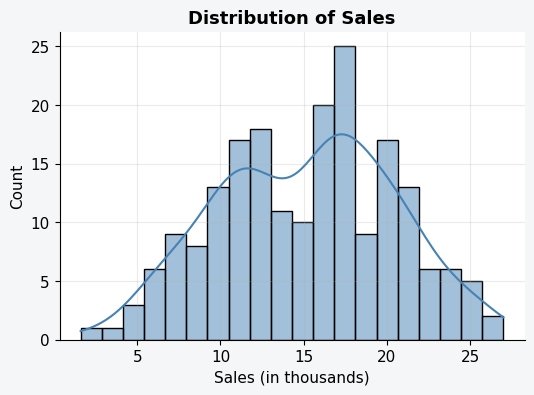

Sales stats:
 count    200.000000
mean      15.130500
std        5.283892
min        1.600000
25%       11.000000
50%       16.000000
75%       19.050000
max       27.000000
Name: Sales, dtype: float64

Skewness of Sales: -0.0737


In [12]:
# Target variable distribution (Sales is continuous, so use histplot)
plt.figure(figsize=(6, 4))
sns.histplot(df['Sales'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales (in thousands)')
plt.show()

print("Sales stats:\n", df['Sales'].describe())
print("\nSkewness of Sales:", round(df['Sales'].skew(), 4))

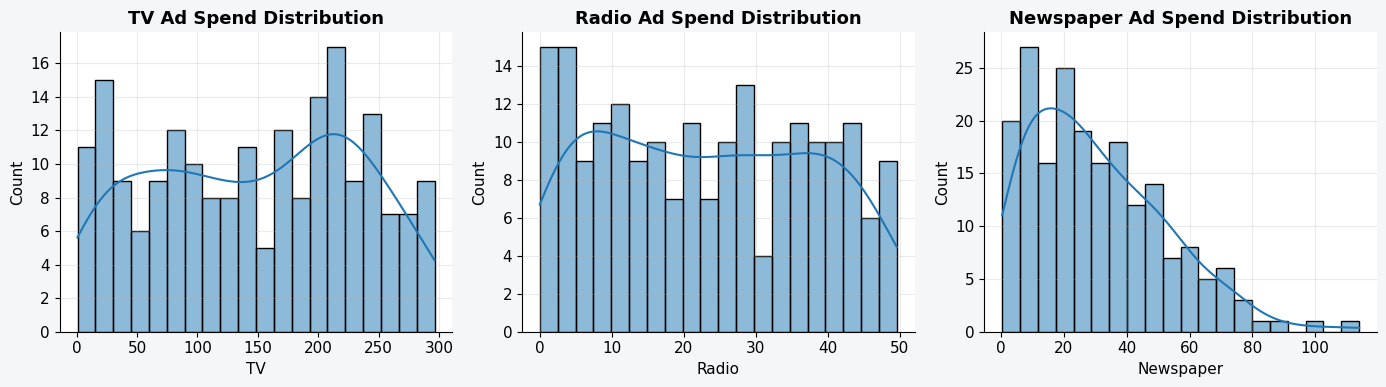

In [13]:
# Advertising spend distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.histplot(df[col], bins=20, kde=True, ax=ax)
    ax.set_title(f'{col} Ad Spend Distribution')
plt.tight_layout()
plt.show()

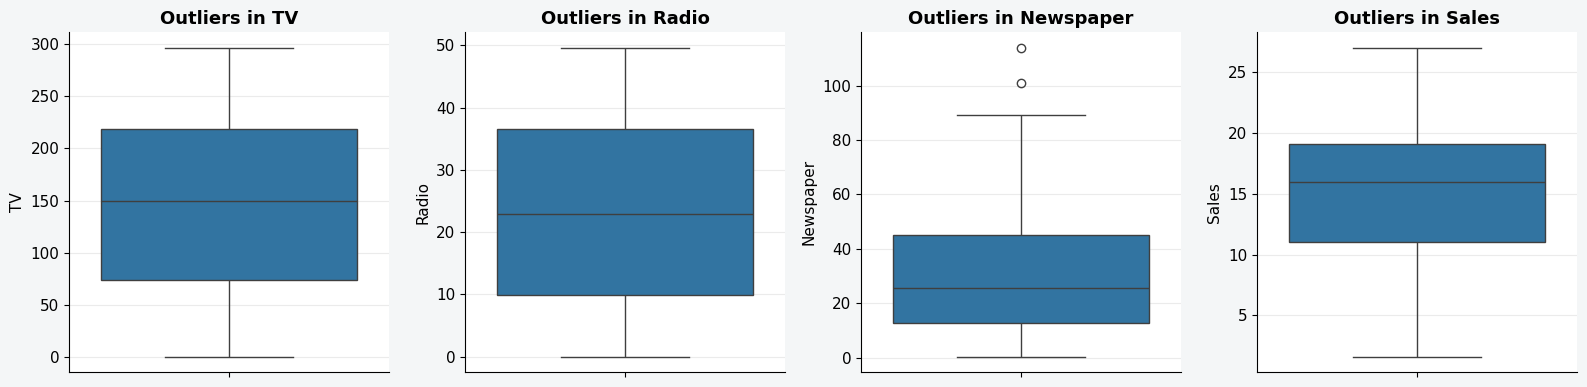

In [14]:
# Outlier check for all features (mirrors the original Amount boxplot)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper', 'Sales']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

Correlation with Sales:
 Sales        1.000000
TV           0.901208
Radio        0.349631
Newspaper    0.157960
Name: Sales, dtype: float64


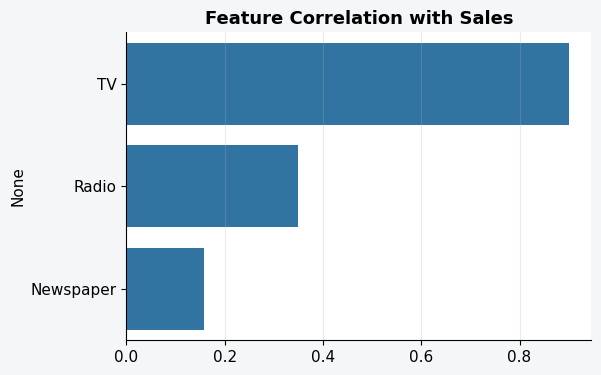

In [15]:
# Correlation with Sales (mirrors the original "top features influencing fraud")
corr = df.corr()['Sales'].sort_values(ascending=False)
print("Correlation with Sales:\n", corr)

plt.figure(figsize=(6, 4))
sns.barplot(x=corr.drop('Sales').values, y=corr.drop('Sales').index)
plt.title('Feature Correlation with Sales')
plt.show()

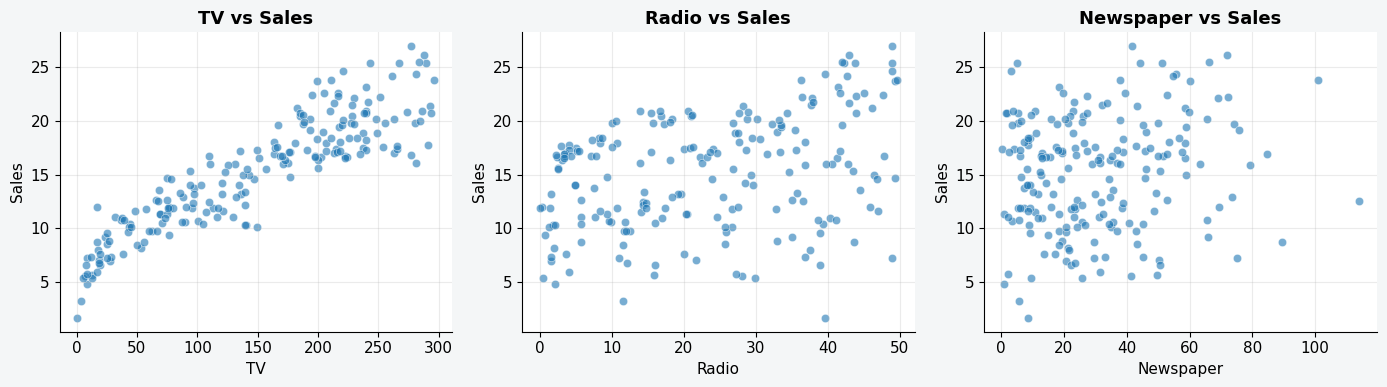

In [16]:

# Scatter plots: each ad channel vs Sales
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    sns.scatterplot(x=df[col], y=df['Sales'], ax=ax, alpha=0.6)
    ax.set_title(f'{col} vs Sales')
plt.tight_layout()
plt.show()

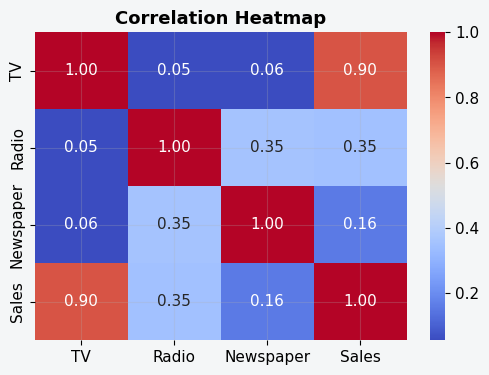

In [17]:
# Full correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### OUTLIER HANDLING

Before capping: (200, 4)
After capping:  (200, 4)


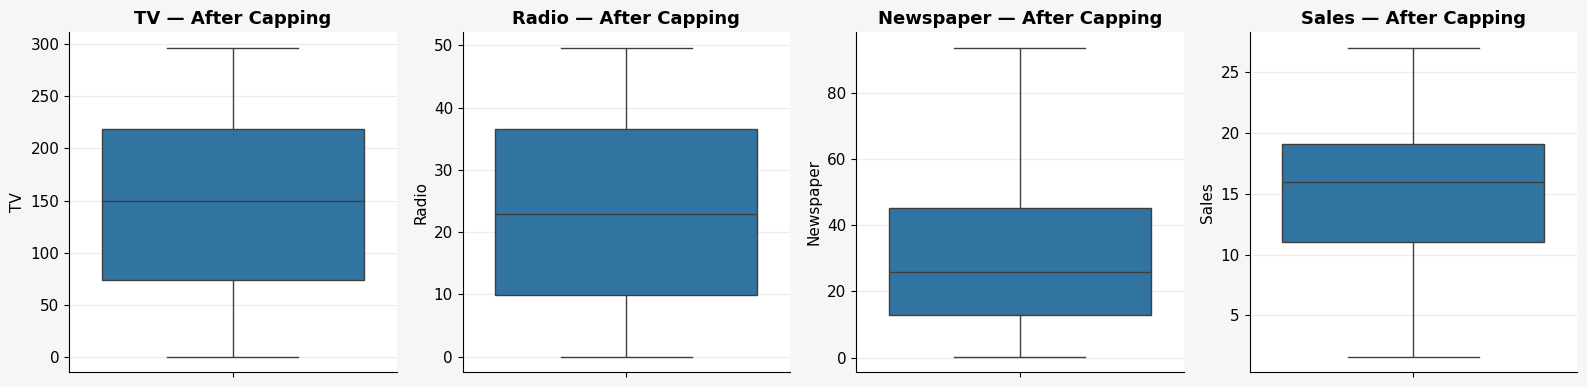

In [18]:
def cap_outliers(df, column):
    """IQR-based outlier capping (winsorization)."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower, upper)
    return df

df_eda = df.copy()   # for visualization
df_model = df.copy() # for ML

for col in ['TV', 'Radio', 'Newspaper', 'Sales']:
    df_eda = cap_outliers(df_eda, col)

print("Before capping:", df.shape)
print("After capping: ", df_eda.shape)

# Verify — boxplots after capping
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper', 'Sales']):
    sns.boxplot(y=df_eda[col], ax=ax)
    ax.set_title(f'{col} — After Capping')
plt.tight_layout()
plt.show()

## Feature engineering and Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

# Interaction feature: TV spend × Radio spend
df_eda['TV_Radio'] = df_eda['TV'] * df_eda['Radio']

# Scaled columns for inspection / linear models
scaler = StandardScaler()
for col in ['TV', 'Radio', 'Newspaper']:
    df_eda[f'{col}_scaled'] = scaler.fit_transform(df_eda[[col]])

print("Skewness check:")
for col in ['TV', 'Radio', 'Newspaper', 'Sales']:
    print(f"  {col}: {df_eda[col].skew():.4f}")

Skewness check:
  TV: -0.0699
  Radio: 0.0942
  Newspaper: 0.7498
  Sales: -0.0737


## Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

# Features and target
FEATURES = ['TV', 'Radio', 'Newspaper', 'TV_Radio']   # including interaction term
TARGET   = 'Sales'

X = df_eda[FEATURES]
y = df_eda[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    # NOTE: no stratify= here — that's for classification targets
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Scale for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train: (160, 4), Test: (40, 4)


## Model Training

In [21]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
# ── Model 1: Linear Regression (replaces Logistic Regression)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [23]:
# ── Model 2: Polynomial Regression degree=2 (same structure as original Poly LR)
poly_pipeline = Pipeline([
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))   # Ridge to avoid overfitting with poly features
])
poly_pipeline.fit(X_train, y_train)
y_pred_poly = poly_pipeline.predict(X_test)

In [24]:
# ── Model 3: Random Forest Regressor (replaces RandomForestClassifier)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [25]:
# ── Model 4: XGBoost Regressor (replaces XGBClassifier)
# NOTE: scale_pos_weight is removed — that was for class imbalance only
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

## Model evaluation

In [26]:
def regression_report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{'─'*40}")
    print(f"  {name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

rows = []
rows.append(regression_report('Linear Regression',     y_test, y_pred_lr))
rows.append(regression_report('Polynomial Regression', y_test, y_pred_poly))
rows.append(regression_report('Random Forest',         y_test, y_pred_rf))
rows.append(regression_report('XGBoost',               y_test, y_pred_xgb))
print("─"*40)

────────────────────────────────────────
  Linear Regression
  RMSE : 1.5451
  MAE  : 1.1949
  R²   : 0.9227
────────────────────────────────────────
  Polynomial Regression
  RMSE : 1.2041
  MAE  : 0.9421
  R²   : 0.9531
────────────────────────────────────────
  Random Forest
  RMSE : 1.0864
  MAE  : 0.7398
  R²   : 0.9618
────────────────────────────────────────
  XGBoost
  RMSE : 0.9548
  MAE  : 0.6284
  R²   : 0.9705
────────────────────────────────────────


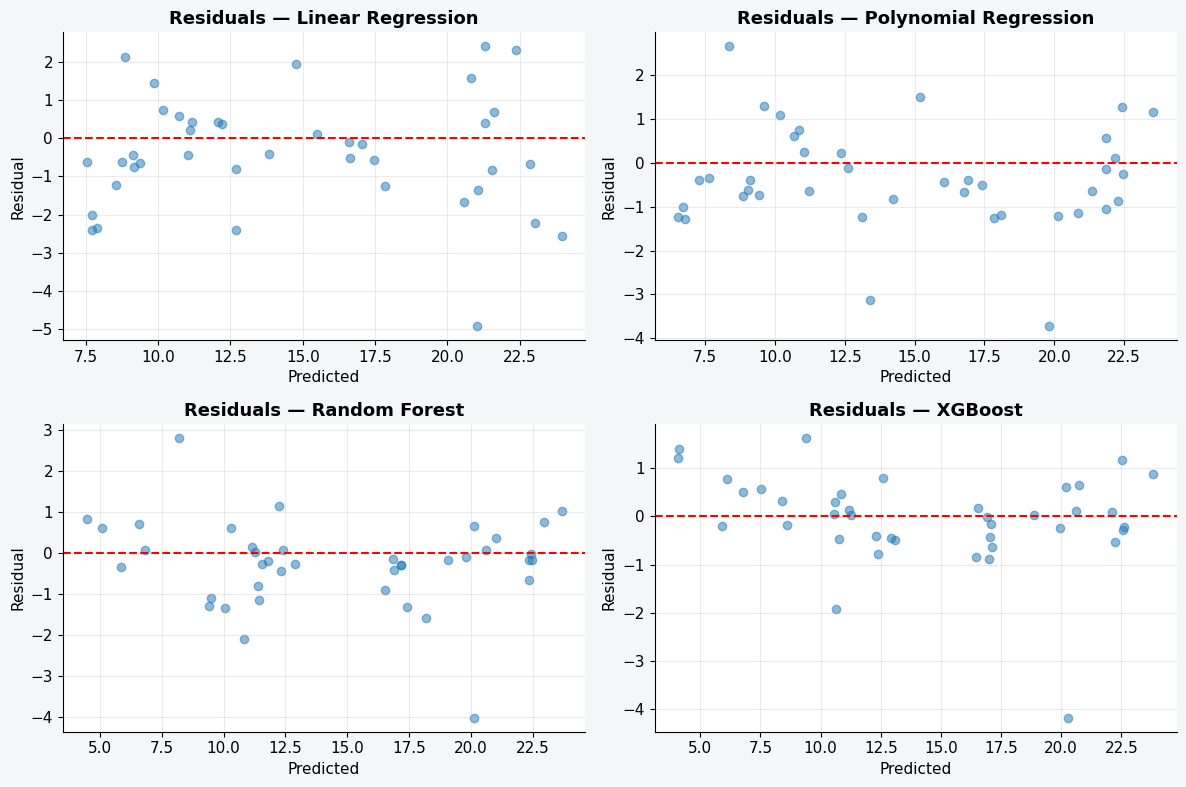

In [27]:
# Residual plot (replaces confusion matrix) — shows where each model errs
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
preds_map = {
    'Linear Regression':     y_pred_lr,
    'Polynomial Regression': y_pred_poly,
    'Random Forest':         y_pred_rf,
    'XGBoost':               y_pred_xgb
}
for ax, (name, y_pred) in zip(axes.ravel(), preds_map.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(f'Residuals — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
plt.tight_layout()
plt.show()

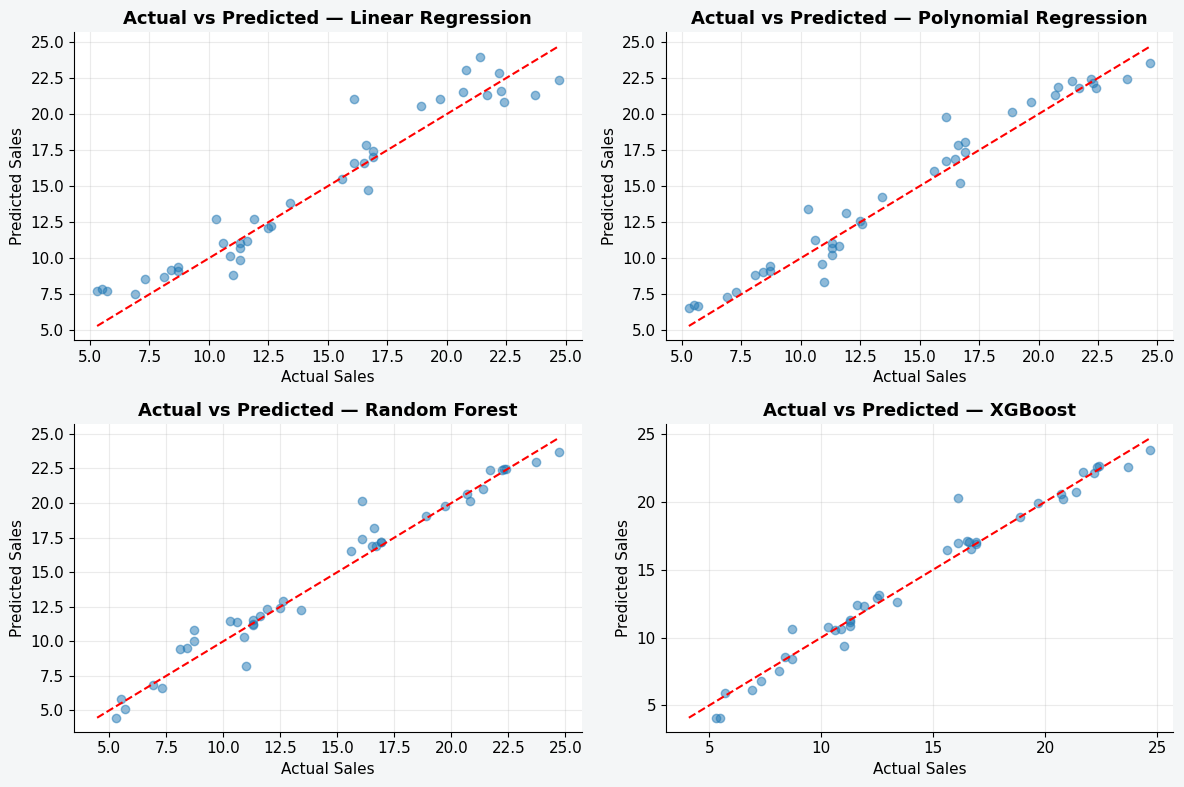

In [28]:
# Actual vs Predicted (replaces ROC curve) — visual fit quality per model
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, y_pred) in zip(axes.ravel(), preds_map.items()):
    ax.scatter(y_test, y_pred, alpha=0.5)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--')
    ax.set_title(f'Actual vs Predicted — {name}')
    ax.set_xlabel('Actual Sales')
    ax.set_ylabel('Predicted Sales')
plt.tight_layout()
plt.show()

## Feature Importance

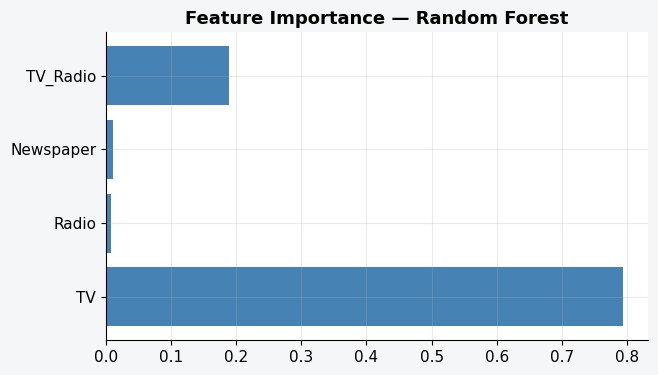

In [29]:
# Random Forest feature importance
importances_rf = rf.feature_importances_

plt.figure(figsize=(7, 4))
plt.barh(FEATURES, importances_rf, color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.show()

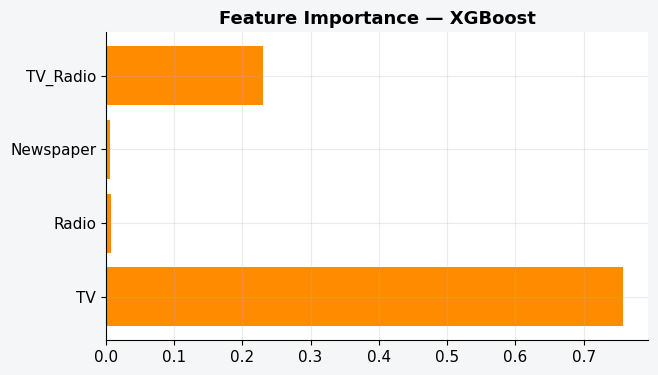

In [30]:
# XGBoost feature importance
importances_xgb = xgb.feature_importances_

plt.figure(figsize=(7, 4))
plt.barh(FEATURES, importances_xgb, color='darkorange')
plt.title('Feature Importance — XGBoost')
plt.show()

## Model Comparison Summary

                Model     RMSE      MAE       R2
              XGBoost 0.954800 0.628395 0.970498
        Random Forest 1.086359 0.739775 0.961808
Polynomial Regression 1.204072 0.942114 0.953083
    Linear Regression 1.545071 1.194851 0.922746


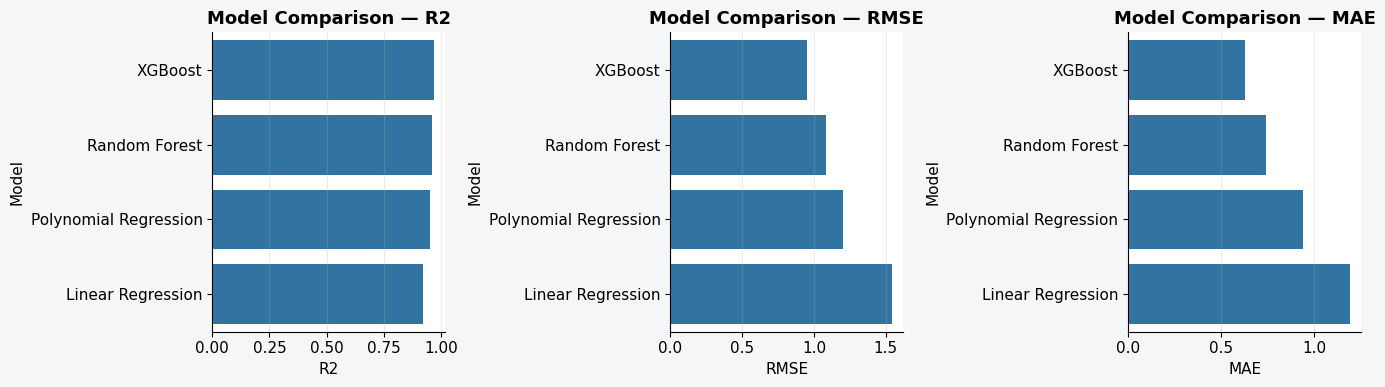

In [31]:
results = pd.DataFrame(rows)
print(results.sort_values(by='R2', ascending=False).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    ascending = metric != 'R2'   # lower is better for error metrics
    data = results.sort_values(by=metric, ascending=ascending)
    sns.barplot(x=metric, y='Model', data=data, ax=ax)
    ax.set_title(f'Model Comparison — {metric}')
plt.tight_layout()
plt.show()